In [2]:
# calculate the CD projection

import numpy as np
from pathlib import Path

from ephys_dimension_reduction_CD import coding_direction_from_psth
from create_psth import load_zarr
from general_utils import smart_read_csv, find_ephys_sessions

# ---------------------------------------------------------------------
# User parameters
# ---------------------------------------------------------------------
binsize = "0.2"
align = "go_cue"

# Each entry is a group of brain regions to pool together.
# An empty list [] means "use all brain regions" for that session.
brain_regions_groups = [
    ["MD"],
    ["MOs2/3", "MOs5", "MOs6a"],
    ["SI", "MA"],
    [],  # empty => no brain-region filter (all units)
]

projection_time_window = None     # None => full peri-event time
two_fold_cv = True                # use the swap split as well
norm_mode = "divide_sqrtN"        # {"none","divide_sqrtN","unit_variance_fit","zscore_fit"}
min_units_num = 30
time_windows = [[0.3, 2], [-1, 0]]
trial_types = ["right_choice_trials", "left_choice_trials"]
# trial_types = ["rewarded_trials", "unrewarded_trials"]

psth_root = Path("/root/capsule/scratch/psth_results")
behavior_root = Path("/root/capsule/scratch/behavior_summary")
cd_root = Path("/root/capsule/scratch/CD_results")
cd_root.mkdir(parents=True, exist_ok=True)

metadata_path = Path("/root/capsule/scratch/qc_passed_units_metadata_all_sessions.csv")

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def _clean_ids(x):
    """
    Convert behavior_summary column (x) into an integer array of trial IDs.
    Assumes x[0] contains the list/array of trial IDs.
    """
    arr = np.asarray(x[0])
    if arr.dtype.kind in {"f"}:  # float -> may contain NaN
        arr = arr[~np.isnan(arr)]
    return arr.astype(int)


# ---------------------------------------------------------------------
# Main loop
# ---------------------------------------------------------------------
sessions = find_ephys_sessions()
failed_sessions = []

metadata = smart_read_csv(metadata_path)

print("Total sessions (index 2):", len(sessions[2]))

for session in sessions[2]:
    print("\n==============================")
    print(f"Session: {session}")
    print("==============================")

    try:
        psth_path = psth_root / f"{session}_{binsize}s.zarr"
        behavior_path = behavior_root / f"behavior_summary-{session}.csv"

        psth_da = load_zarr(str(psth_path))
        df = smart_read_csv(str(behavior_path))

        # Pull trial-id arrays and clean up (drop NaN, cast to int)
        typeA_ids = _clean_ids(df[trial_types[0]])
        typeB_ids = _clean_ids(df[trial_types[1]])

        # -----------------------------------------------------------------
        # Loop over brain region groups
        # -----------------------------------------------------------------
        for region_group in brain_regions_groups:
            # Build a safe label for filenames
            if region_group:
                safe_parts = [r.replace("/", "_") for r in region_group]
                region_label = "RG_" + "_".join(safe_parts)
                region_print = ", ".join(region_group)
            else:
                region_label = "RG_ALL"
                region_print = "ALL"

            # Build mask on metadata for this session and region group
            if region_group:
                mask = (
                    (metadata["sorted_session_name"] == session)
                    & (metadata["brain_region"].isin(region_group))
                )
            else:
                # No region filter → take all units for this session
                mask = (metadata["sorted_session_name"] == session)

            unit_indices = metadata.loc[mask, "unit_index"].to_numpy()

            if len(unit_indices) < min_units_num:
                print(
                    f"  Skip region {region_label} ({region_print}): "
                    f"{len(unit_indices)} units < min {min_units_num}"
                )
                continue

            print(
                f"  Region {region_label} ({region_print}): "
                f"{len(unit_indices)} units"
            )

            # -------------------------------------------------------------
            # Loop over time windows
            # -------------------------------------------------------------
            for time_window in time_windows:
                tw0, tw1 = time_window

                save_path = (
                    cd_root
                    / f"CD_{session}_{region_label}_{trial_types[0]}_{trial_types[1]}"
                    f"_TW_{tw0}_{tw1}.zarr"
                )

                try:
                    out = coding_direction_from_psth(
                        psth_da=psth_da,
                        trial_ids_typeA=typeA_ids,
                        trial_ids_typeB=typeB_ids,
                        align=align,
                        time_window=tuple(time_window),
                        projection_time_window=projection_time_window,
                        random_state=0,
                        two_fold_cv=two_fold_cv,
                        norm_mode=norm_mode,
                        save_path=str(save_path),
                        save_format="zarr",
                        overwrite=True,
                        unit_ids=unit_indices,  # brain-region (or all) subset
                    )

                    print(
                        f"    ✔ Finished time window {time_window}: "
                        f"{out.get('saved_to', str(save_path))}"
                    )

                except Exception as e:
                    print(f"    ❌ Error in time window {time_window}: {e}")
                    failed_sessions.append(
                        (session, region_label, f"time_window={time_window}", str(e))
                    )

    except Exception as e:
        print(f"❌ ERROR loading session {session}: {e}")
        failed_sessions.append((session, "load_failure", str(e)))


print("\n==============================")
print("All sessions done.")
print("==============================")
if failed_sessions:
    print("Failed items:")
    for f in failed_sessions:
        print(" -", f)
else:
    print("No errors 🎉")


Total sessions (index 2): 41

Session: ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25
  Skip region RG_MD (MD): 0 units < min 30
  Skip region RG_MOs2_3_MOs5_MOs6a (MOs2/3, MOs5, MOs6a): 0 units < min 30
  Skip region RG_SI_MA (SI, MA): 0 units < min 30
  Region RG_ALL (ALL): 528 units
    ✔ Finished time window [0.3, 2]: /root/capsule/scratch/CD_results/CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
    ✔ Finished time window [-1, 0]: /root/capsule/scratch/CD_results/CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr

Session: ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58
  Skip region RG_MD (MD): 0 units < min 30
  Skip region RG_MOs2_3_MOs5_MOs6a (MOs2/3, MOs5, MOs6a): 0 units < min 30
  Skip region RG_SI_MA (SI, MA): 0 units < min 30
  Region RG_ALL (ALL): 248 units
    ✔ Finished time window [0.3, 2]: 

[skip] does not match required suffix: CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_753125_2024-10-10_14-41-23_sorted_2024-11-09_20-18-36_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_753125_2024-10-10_14-41-23_sorted_2024-11-09_20-18-36_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not mat

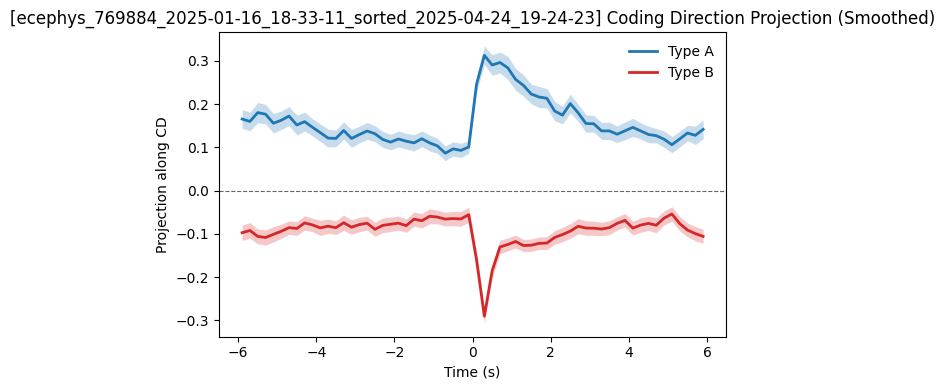

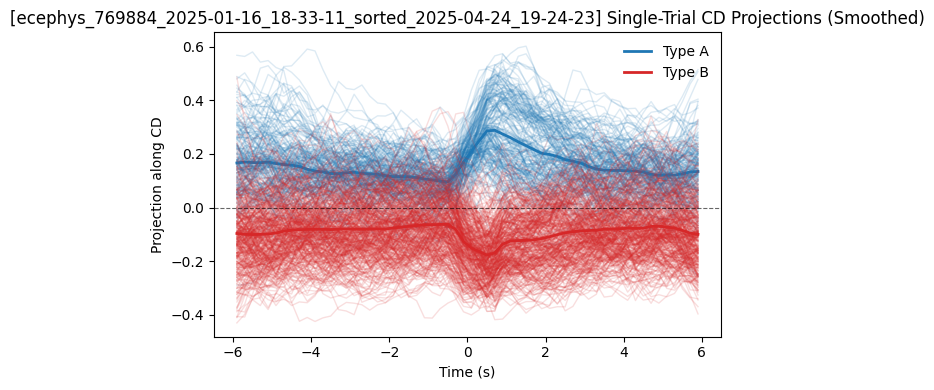

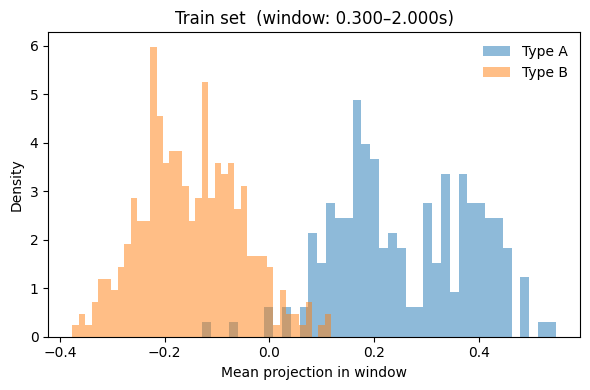

[skip] does not match required suffix: CD_ecephys_776293_2025-02-14_15-19-17_sorted_2025-02-28_21-37-07_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_776293_2025-02-14_15-19-17_sorted_2025-02-28_21-37-07_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_776293_2025-02-14_15-19-17_sorted_2025-02-28_21-37-07_RG_SI_MA_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_776293_2025-02-14_15-19-17_sorted_2025-02-28_21-37-07_RG_SI_MA_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_776293_2025-02-18_12-51-36_sorted_2025-03-30_05-50-33_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_776293_2025-02-18_12-51-36_sorted_2025-03-30_05-50-33_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not

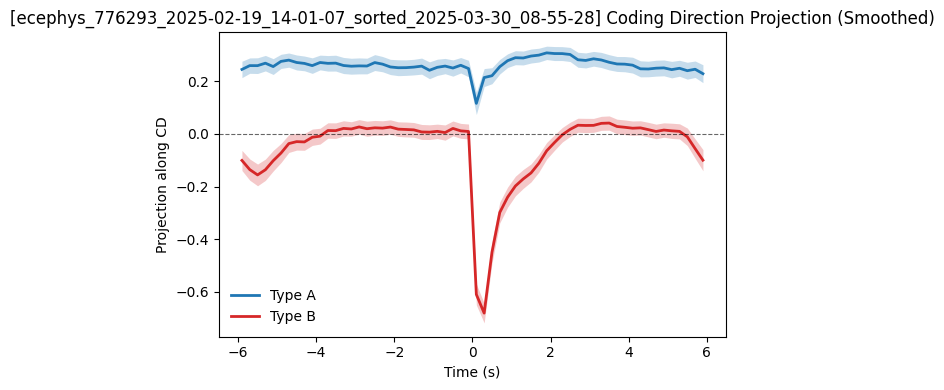

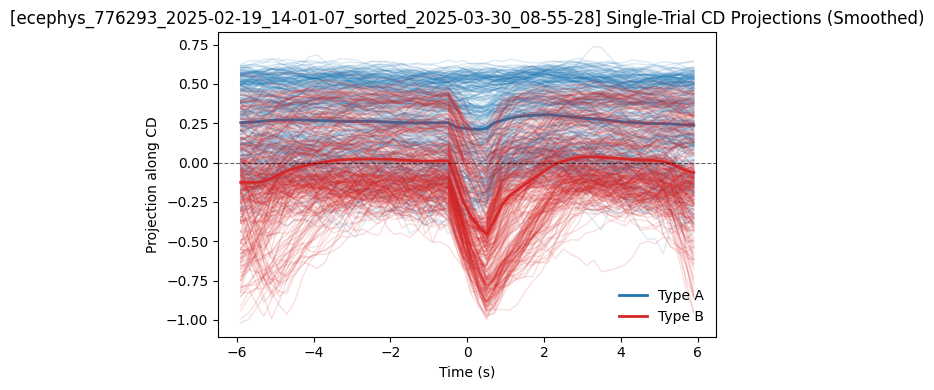

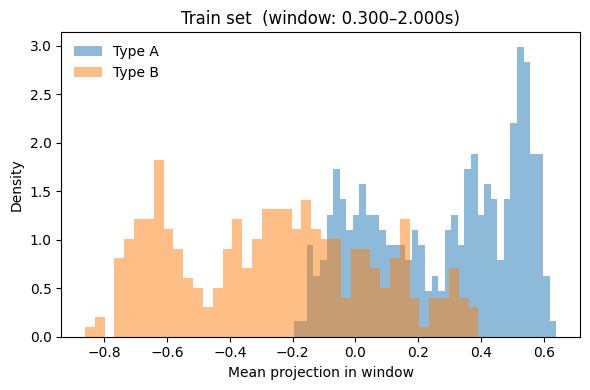

[skip] does not match required suffix: CD_ecephys_780618_2025-04-15_13-30-58_sorted_2025-04-18_12-52-04_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_780618_2025-04-15_13-30-58_sorted_2025-04-18_12-52-04_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_780618_2025-04-15_13-30-58_sorted_2025-04-18_12-52-04_RG_SI_MA_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_780618_2025-04-15_13-30-58_sorted_2025-04-18_12-52-04_RG_SI_MA_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_780618_2025-04-16_15-54-21_sorted_2025-04-18_12-51-23_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_780618_2025-04-16_15-54-21_sorted_2025-04-18_12-51-23_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not

In [3]:
# single sessions
import os
import re
import glob
import numpy as np
import xarray as xr
import pandas as pd
from general_utils import smart_read_csv
from ephys_dimension_reduction_CD_visualization import plot_cd_window_distribution, plot_cd_projection
# --- Config ---
base_dir = "/root/capsule/scratch/CD_results/"
zarr_glob = os.path.join(base_dir, "CD_*.zarr")

# Only process files containing this exact substring
#required_suffix = "_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_-1_0"
required_suffix = "_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_0.3_2"

# Regex to extract the session name (general; keeps your existing session_re logic)
session_re = re.compile(r"^CD_(?P<session>.+?)_RG_")

distribution_window = (0.3, 2)

def select_traces_by_switch(proj, trial_ids, switch_ids):
    mask = np.isin(trial_ids, switch_ids)
    return proj[mask], trial_ids[mask]

summ_rows = []

# --------------------------------------------------------------------------
# Loop over CD files
# --------------------------------------------------------------------------
for zpath in sorted(glob.glob(zarr_glob)):
    zname = os.path.basename(zpath)

    # 🔥 Only keep files containing the required region + TW substring
    if required_suffix not in zname:
        print(f"[skip] does not match required suffix: {zname}")
        continue

    # Extract session name
    m = session_re.match(zname)
    if not m:
        print(f"[skip] cannot extract session from: {zname}")
        continue

    session_name = m.group("session")

    # Behavior CSV path
    beh_csv = f"/root/capsule/scratch/behavior_summary/behavior_summary-{session_name}.csv"
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session_name} -> {beh_csv}")
        continue

    print(f"\n=== Session: {session_name} ===")
    print("File:", zname)

    # --- Load behavior + CD dataset ---
    df = smart_read_csv(beh_csv)
    ds = xr.open_zarr(zpath, consolidated=False)

    # --- Time & PSTH ---
    time = ds["time"].values
    dt = float(np.mean(np.diff(time))) if len(time) > 1 else np.nan

    # --- Load trial IDs from dataset ---
    trial_id_test_A  = ds["trial_id_test_A"].values.astype(int)
    trial_id_test_B  = ds["trial_id_test_B"].values.astype(int)
    trial_id_train_A = ds["trial_id_train_A"].values.astype(int)
    trial_id_train_B = ds["trial_id_train_B"].values.astype(int)

    # --- Projection traces ---
    proj_train_A = ds["projection_trace_train_A"].values
    proj_train_B = ds["projection_trace_train_B"].values
    proj_test_A  = ds["projection_trace_test_A"].values
    proj_test_B  = ds["projection_trace_test_B"].values

    # --- Switch trial sets from behavior ---
    switch_LR = np.asarray(df["switch_LR_trials"][0], dtype=int)
    switch_RL = np.asarray(df["switch_RL_trials"][0], dtype=int)

    # --- Subsets by LR / RL switches ---
    proj_train_A_LR, trial_train_A_LR = select_traces_by_switch(proj_train_A, trial_id_train_A, switch_LR)
    proj_train_A_RL, trial_train_A_RL = select_traces_by_switch(proj_train_A, trial_id_train_A, switch_RL)

    proj_train_B_LR, trial_train_B_LR = select_traces_by_switch(proj_train_B, trial_id_train_B, switch_LR)
    proj_train_B_RL, trial_train_B_RL = select_traces_by_switch(proj_train_B, trial_id_train_B, switch_RL)

    proj_test_A_LR, trial_test_A_LR = select_traces_by_switch(proj_test_A, trial_id_test_A, switch_LR)
    proj_test_A_RL, trial_test_A_RL = select_traces_by_switch(proj_test_A, trial_id_test_A, switch_RL)

    proj_test_B_LR, trial_test_B_LR = select_traces_by_switch(proj_test_B, trial_id_test_B, switch_LR)
    proj_test_B_RL, trial_test_B_RL = select_traces_by_switch(proj_test_B, trial_id_test_B, switch_RL)

    print("Train A  (LR / RL):", proj_train_A_LR.shape[0], "/", proj_train_A_RL.shape[0])
    print("Train B  (LR / RL):", proj_train_B_LR.shape[0], "/", proj_train_B_RL.shape[0])
    print("Test  A  (LR / RL):", proj_test_A_LR.shape[0], "/", proj_test_A_RL.shape[0])
    print("Test  B  (LR / RL):", proj_test_B_LR.shape[0], "/", proj_test_B_RL.shape[0])

    summ_rows.append({
        "session": session_name,
        "train_A_LR_n": int(proj_train_A_LR.shape[0]),
        "train_A_RL_n": int(proj_train_A_RL.shape[0]),
        "train_B_LR_n": int(proj_train_B_LR.shape[0]),
        "train_B_RL_n": int(proj_train_B_RL.shape[0]),
        "test_A_LR_n": int(proj_test_A_LR.shape[0]),
        "test_A_RL_n": int(proj_test_A_RL.shape[0]),
        "test_B_LR_n": int(proj_test_B_LR.shape[0]),
        "test_B_RL_n": int(proj_test_B_RL.shape[0]),
    })

    # --- Plotting ---
    try:
        plot_cd_projection(
            time,
            proj_train_A, proj_train_B,
            average=True, 
            smooth=0.1, dt=dt, smooth_mode="gaussian",
            title=f"[{session_name}] Coding Direction Projection (Smoothed)"
        )

        plot_cd_projection(
            time,
            proj_train_A, proj_train_B,
            average=False,
            smooth=5, smooth_mode="moving",
            title=f"[{session_name}] Single-Trial CD Projections (Smoothed)"
        )

        plot_cd_window_distribution(
            time, proj_train_A, proj_train_B,
            window=distribution_window,
            kind="hist",
            bins=40,
            hist_overlay=True,
            title="Train set"
        )

    except NameError:
        print("plot_cd_projection not found; skipping plots.")

# --- Summary table ---
if summ_rows:
    summary_df = pd.DataFrame(summ_rows)
    summary_csv = os.path.join(base_dir, "CD_sessions_switch_counts_summary.csv")
    summary_df.to_csv(summary_csv, index=False)
    print("\nSaved summary:", summary_csv)
else:
    print("No sessions processed.")



=== Session: ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23 ===
Zarr: /root/capsule/scratch/CD_results/CD_ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_-1_0.zarr
CSV : /root/capsule/scratch/behavior_summary/behavior_summary-ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23.csv
Train A  (LR / RL): 11 / 0
Train B  (LR / RL): 0 / 13
Test  A  (LR / RL): 11 / 0
Test  B  (LR / RL): 0 / 13

=== Session: ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28 ===
Zarr: /root/capsule/scratch/CD_results/CD_ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_-1_0.zarr
CSV : /root/capsule/scratch/behavior_summary/behavior_summary-ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28.csv
Train A  (LR / RL): 12 / 0
Train B  (LR / RL): 0 / 13
Test  A  (LR / RL): 12 / 0
Test  B  (LR / RL): 0 / 13

Summary acros

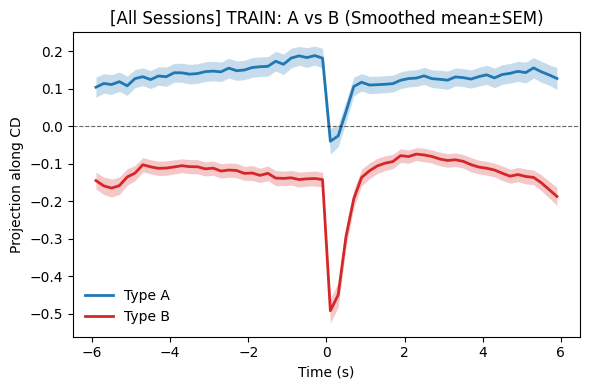

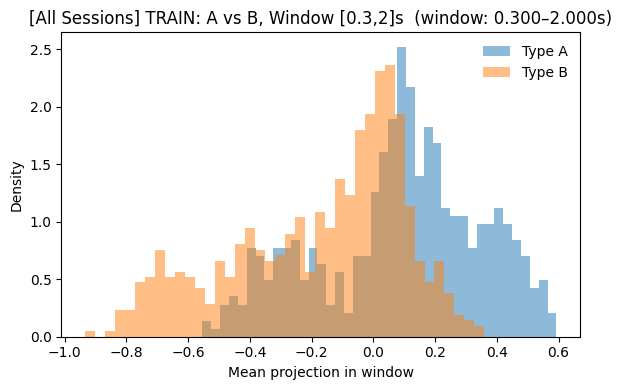

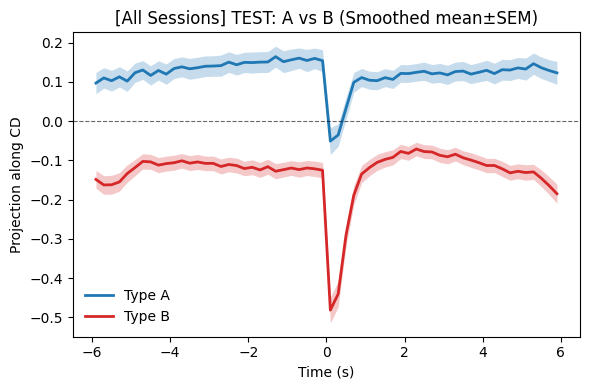

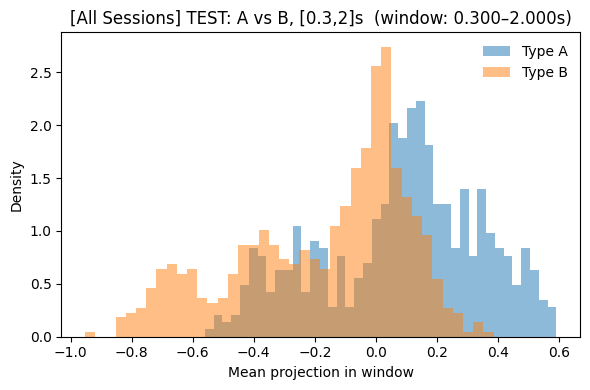

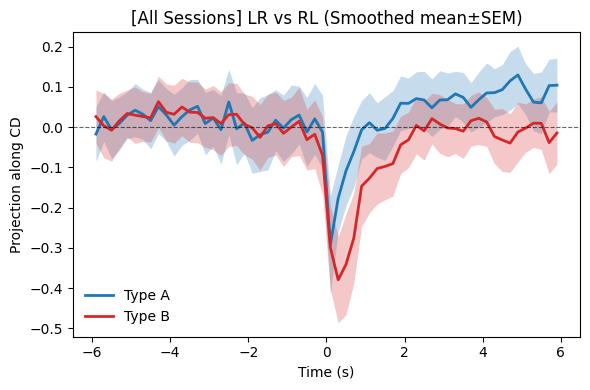

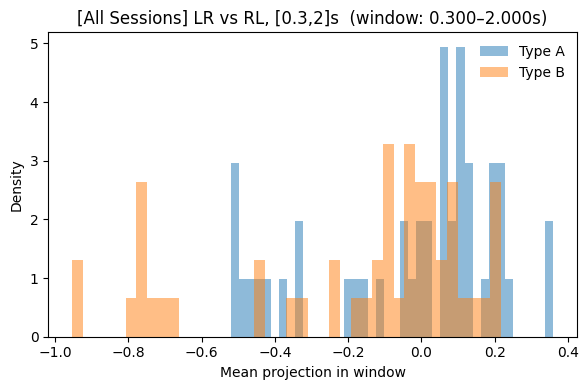

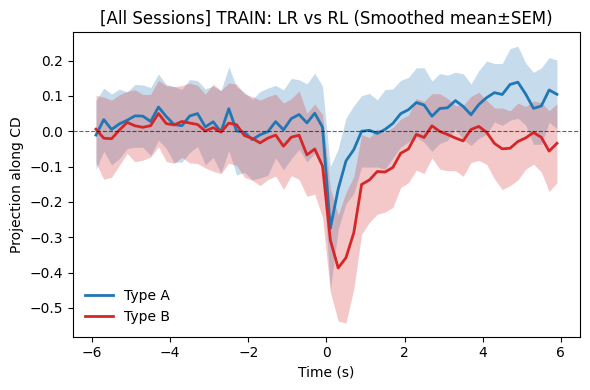

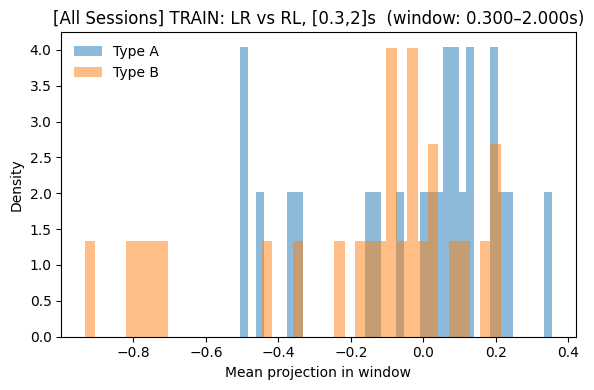

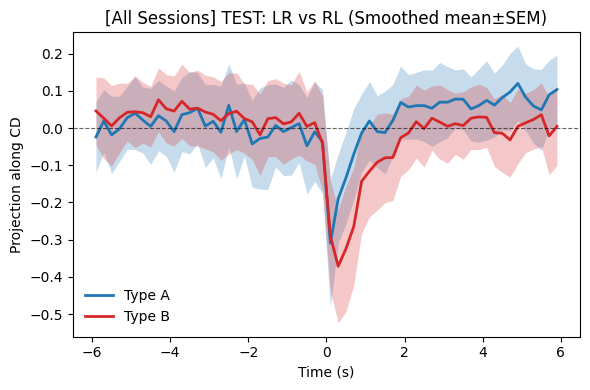

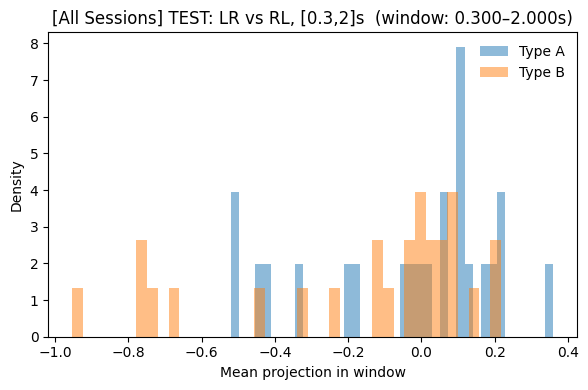

In [4]:
# combined sessions

import os
import re
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from general_utils import smart_read_csv
from ephys_dimension_reduction_CD_visualization import plot_cd_window_distribution, plot_cd_projection
# =========================
# Config
# =========================
base_dir = "/root/capsule/scratch"
results_dir = os.path.join(base_dir, "CD_results")

# Choose which files you want:
target_suffix = "_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_-1_0"
#target_suffix = "_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_0.3_2"
distribution_window = (0.3, 2)
# or:
#target_suffix = "_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0"
# or:
# target_suffix = "_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2"

# Only files containing this suffix:
zarr_glob = os.path.join(results_dir, f"CD_*{target_suffix}.zarr")



# Extract session name between "CD_" and "_RG_"
session_re = re.compile(r"^CD_(?P<session>.+?)_RG_")

# =========================
# Helpers (same as before)
# =========================
def select_traces_by_switch(proj, trial_ids, switch_ids):
    mask = np.isin(trial_ids, switch_ids)
    return proj[mask], trial_ids[mask]

def cat_or_none(lst):
    if not lst:
        return None
    arrs = [a for a in lst if isinstance(a, np.ndarray) and a.ndim == 2 and a.size > 0]
    if not arrs:
        return None
    return np.concatenate(arrs, axis=0)

def concat_ids(lst):
    if not lst:
        return np.array([], dtype=int)
    arrs = [a for a in lst if isinstance(a, np.ndarray) and a.ndim == 1 and a.size > 0]
    if not arrs:
        return np.array([], dtype=int)
    return np.concatenate(arrs, axis=0)

# =========================
# Aggregators definitions
# =========================
cats = {
    "train_A_LR": [], "train_A_RL": [],
    "train_B_LR": [], "train_B_RL": [],
    "test_A_LR":  [], "test_A_RL":  [],
    "test_B_LR":  [], "test_B_RL":  [],
}
trial_ids_cats = {k: [] for k in cats.keys()}
session_tags_cats = {k: [] for k in cats.keys()}

raw_cats = {
    "train_A_all": [],
    "train_B_all": [],
    "test_A_all":  [],
    "test_B_all":  [],
}

summ_rows = []
global_time = None
global_dt = np.nan

# =========================
# Main loop
# =========================
for zpath in sorted(glob.glob(zarr_glob)):
    zname = os.path.basename(zpath)

    m = session_re.match(zname)
    if not m:
        print(f"[skip] cannot extract session from: {zname}")
        continue
    session_name = m.group("session")

    beh_csv = os.path.join(base_dir, f"behavior_summary/behavior_summary-{session_name}.csv")
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {zname} -> {beh_csv}")
        continue

    print(f"\n=== Session: {session_name} ===")
    print(f"Zarr: {zpath}")
    print(f"CSV : {beh_csv}")

    df = smart_read_csv(beh_csv)
    ds = xr.open_zarr(zpath, consolidated=False)

    time = ds["time"].values
    dt = float(np.mean(np.diff(time))) if len(time) > 1 else np.nan
    if global_time is None:
        global_time = time
        global_dt = dt
    else:
        if len(time) != len(global_time) or not np.allclose(time, global_time):
            print("[warn] time axis differs from previous sessions; concatenation assumes identical length.")

    trial_id_test_A  = np.asarray(ds["trial_id_test_A"].values, dtype=int)
    trial_id_test_B  = np.asarray(ds["trial_id_test_B"].values, dtype=int)
    trial_id_train_A = np.asarray(ds["trial_id_train_A"].values, dtype=int)
    trial_id_train_B = np.asarray(ds["trial_id_train_B"].values, dtype=int)

    proj_train_A = ds["projection_trace_train_A"].values
    proj_train_B = ds["projection_trace_train_B"].values
    proj_test_A  = ds["projection_trace_test_A"].values
    proj_test_B  = ds["projection_trace_test_B"].values

    # Unfiltered
    if isinstance(proj_train_A, np.ndarray) and proj_train_A.ndim == 2 and proj_train_A.size > 0:
        raw_cats["train_A_all"].append(proj_train_A)
    if isinstance(proj_train_B, np.ndarray) and proj_train_B.ndim == 2 and proj_train_B.size > 0:
        raw_cats["train_B_all"].append(proj_train_B)
    if isinstance(proj_test_A, np.ndarray) and proj_test_A.ndim == 2 and proj_test_A.size > 0:
        raw_cats["test_A_all"].append(proj_test_A)
    if isinstance(proj_test_B, np.ndarray) and proj_test_B.ndim == 2 and proj_test_B.size > 0:
        raw_cats["test_B_all"].append(proj_test_B)

    switch_LR = np.asarray(df["switch_LR_trials"][0], dtype=int)
    switch_RL = np.asarray(df["switch_RL_trials"][0], dtype=int)

    train_A_LR, ids_train_A_LR = select_traces_by_switch(proj_train_A, trial_id_train_A, switch_LR)
    train_A_RL, ids_train_A_RL = select_traces_by_switch(proj_train_A, trial_id_train_A, switch_RL)

    train_B_LR, ids_train_B_LR = select_traces_by_switch(proj_train_B, trial_id_train_B, switch_LR)
    train_B_RL, ids_train_B_RL = select_traces_by_switch(proj_train_B, trial_id_train_B, switch_RL)

    test_A_LR, ids_test_A_LR = select_traces_by_switch(proj_test_A, trial_id_test_A, switch_LR)
    test_A_RL, ids_test_A_RL = select_traces_by_switch(proj_test_A, trial_id_test_A, switch_RL)

    test_B_LR, ids_test_B_LR = select_traces_by_switch(proj_test_B, trial_id_test_B, switch_LR)
    test_B_RL, ids_test_B_RL = select_traces_by_switch(proj_test_B, trial_id_test_B, switch_RL)

    def append_cat(key, X, ids):
        if isinstance(X, np.ndarray) and X.ndim == 2 and X.size > 0:
            cats[key].append(X)
            trial_ids_cats[key].append(ids)
            session_tags_cats[key].extend([session_name] * X.shape[0])

    append_cat("train_A_LR", train_A_LR, ids_train_A_LR)
    append_cat("train_A_RL", train_A_RL, ids_train_A_RL)
    append_cat("train_B_LR", train_B_LR, ids_train_B_LR)
    append_cat("train_B_RL", train_B_RL, ids_train_B_RL)

    append_cat("test_A_LR",  test_A_LR,  ids_test_A_LR)
    append_cat("test_A_RL",  test_A_RL,  ids_test_A_RL)
    append_cat("test_B_LR",  test_B_LR,  ids_test_B_LR)
    append_cat("test_B_RL",  test_B_RL,  ids_test_B_RL)

    print("Train A  (LR / RL):", train_A_LR.shape[0], "/", train_A_RL.shape[0])
    print("Train B  (LR / RL):", train_B_LR.shape[0], "/", train_B_RL.shape[0])
    print("Test  A  (LR / RL):", test_A_LR.shape[0],  "/", test_A_RL.shape[0])
    print("Test  B  (LR / RL):", test_B_LR.shape[0],  "/", test_B_RL.shape[0])

    summ_rows.append({
        "session": session_name,
        "train_A_LR_n": int(train_A_LR.shape[0]),
        "train_A_RL_n": int(train_A_RL.shape[0]),
        "train_B_LR_n": int(train_B_LR.shape[0]),
        "train_B_RL_n": int(train_B_RL.shape[0]),
        "test_A_LR_n": int(test_A_LR.shape[0]),
        "test_A_RL_n": int(test_A_RL.shape[0]),
        "test_B_LR_n": int(test_B_LR.shape[0]),
        "test_B_RL_n": int(test_B_RL.shape[0]),
    })

# (rest of concatenation + plotting part of your script can remain unchanged)

# =========================
# Concatenate across sessions
# =========================
cats_concat = {k: cat_or_none(v) for k, v in cats.items()}
trial_ids_concat = {k: concat_ids(v) for k, v in trial_ids_cats.items()}
session_tags_concat = {k: np.asarray(v, dtype=object) for k, v in session_tags_cats.items()}

# Unfiltered A/B pools
raw_concat = {k: cat_or_none(v) for k, v in raw_cats.items()}

# Also build pooled LR vs RL across A∪B (train and test separately and combined)
pooled = {
    "train_LR": cat_or_none([cats_concat.get("train_A_LR"), cats_concat.get("train_B_LR")]),
    "train_RL": cat_or_none([cats_concat.get("train_A_RL"), cats_concat.get("train_B_RL")]),
    "test_LR":  cat_or_none([cats_concat.get("test_A_LR"),  cats_concat.get("test_B_LR")]),
    "test_RL":  cat_or_none([cats_concat.get("test_A_RL"),  cats_concat.get("test_B_RL")]),
}
pooled["all_LR"] = cat_or_none([pooled["train_LR"], pooled["test_LR"]])
pooled["all_RL"] = cat_or_none([pooled["train_RL"], pooled["test_RL"]])

# =========================
# Save summary CSV
# =========================
if summ_rows:
    summary_df = pd.DataFrame(summ_rows)
    print("\nSummary across sessions:")
    print(summary_df)
    summary_csv = os.path.join(base_dir, "CD_sessions_switch_counts_summary.csv")
    summary_df.to_csv(summary_csv, index=False)
    print(f"Saved summary: {summary_csv}")
else:
    print("No sessions processed.")

# =========================
# Visualizations (average curves + distributions only)
# Using your existing functions; NO single-trial plots
# =========================
if global_time is None:
    print("[viz] No data aggregated; skip plots.")
else:
    # ---- A) Combined (unfiltered) A vs B ----
    try:
        # TRAIN: mean±SEM
        plot_cd_projection(
            global_time,
            raw_concat["train_A_all"], raw_concat["train_B_all"],
            average=True, 
            smooth=0.1, dt=global_dt, smooth_mode="gaussian",
            title="[All Sessions] TRAIN: A vs B (Smoothed mean±SEM)"
        )
        # TRAIN: distribution in window
        plot_cd_window_distribution(
            global_time,
            raw_concat["train_A_all"], raw_concat["train_B_all"],
            window=distribution_window,
            kind="hist",
            bins=40,
            hist_overlay=True,
            title=f"[All Sessions] TRAIN: A vs B, Window [{distribution_window[0]},{distribution_window[1]}]s"
        )

        # TEST: mean±SEM
        plot_cd_projection(
            global_time,
            raw_concat["test_A_all"], raw_concat["test_B_all"],
            average=True, 
            smooth=0.1, dt=global_dt, smooth_mode="gaussian",
            title="[All Sessions] TEST: A vs B (Smoothed mean±SEM)"
        )
        # TEST: distribution in window
        plot_cd_window_distribution(
            global_time,
            raw_concat["test_A_all"], raw_concat["test_B_all"],
            window=distribution_window,
            kind="hist",
            bins=40,
            hist_overlay=True,
            title=f"[All Sessions] TEST: A vs B, [{distribution_window[0]},{distribution_window[1]}]s"
        )
    except NameError:
        print("plot_cd_projection/plot_cd_window_distribution not found; skipping A vs B plots.")

    # ---- B) LR vs RL views: ALL, TRAIN, TEST (mean±SEM + distributions) ----
    try:
        # ALL: mean±SEM
        plot_cd_projection(
            global_time,
            pooled["all_LR"], pooled["all_RL"],
            average=True, 
            smooth=0.1, dt=global_dt, smooth_mode="gaussian",
            title="[All Sessions] LR vs RL (Smoothed mean±SEM)"
        )
        # ALL: distribution
        plot_cd_window_distribution(
            global_time,
            pooled["all_LR"], pooled["all_RL"],
            window=distribution_window,
            kind="hist",
            bins=40,
            hist_overlay=True,
            title=f"[All Sessions] LR vs RL, [{distribution_window[0]},{distribution_window[1]}]s"
        )

        # TRAIN: mean±SEM
        plot_cd_projection(
            global_time,
            pooled["train_LR"], pooled["train_RL"],
            average=True, 
            smooth=0.1, dt=global_dt, smooth_mode="gaussian",
            title="[All Sessions] TRAIN: LR vs RL (Smoothed mean±SEM)"
        )
        # TRAIN: distribution
        plot_cd_window_distribution(
            global_time,
            pooled["train_LR"], pooled["train_RL"],
            window=distribution_window,
            kind="hist",
            bins=40,
            hist_overlay=True,
            title=f"[All Sessions] TRAIN: LR vs RL, [{distribution_window[0]},{distribution_window[1]}]s"
        )

        # TEST: mean±SEM
        plot_cd_projection(
            global_time,
            pooled["test_LR"], pooled["test_RL"],
            average=True, 
            smooth=0.1, dt=global_dt, smooth_mode="gaussian",
            title="[All Sessions] TEST: LR vs RL (Smoothed mean±SEM)"
        )
        # TEST: distribution
        plot_cd_window_distribution(
            global_time,
            pooled["test_LR"], pooled["test_RL"],
            window=distribution_window,
            kind="hist",
            bins=40,
            hist_overlay=True,
            title=f"[All Sessions] TEST: LR vs RL, [{distribution_window[0]},{distribution_window[1]}]s"
        )
    except NameError:
        print("plot_cd_projection/plot_cd_window_distribution not found; skipping LR vs RL plots.")

    plt.show()



=== Session: ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23 ===
Zarr: /root/capsule/scratch/CD_results/CD_ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_-1_0.zarr
CSV : /root/capsule/scratch/behavior_summary/behavior_summary-ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23.csv

=== Session: ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28 ===
Zarr: /root/capsule/scratch/CD_results/CD_ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_-1_0.zarr
CSV : /root/capsule/scratch/behavior_summary/behavior_summary-ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28.csv
[choice-prob] TRAIN: quantile binning, counts=[58, 58, 57, 58, 57, 58, 57, 58, 57, 58, 58, 57, 58, 57, 58, 57, 58, 57, 58, 58]
[choice-prob] TEST: quantile binning, counts=[58, 58, 57, 58, 57, 58, 57, 58, 57, 58, 58, 57, 58, 57, 5

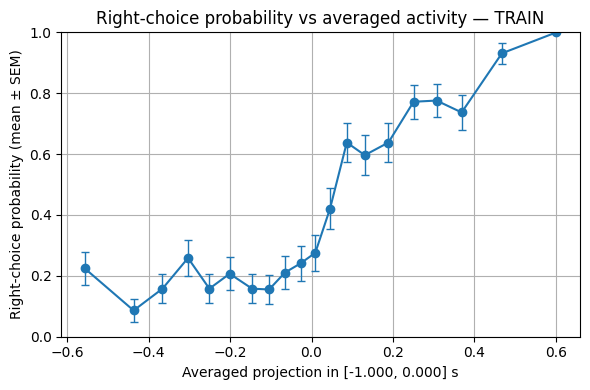

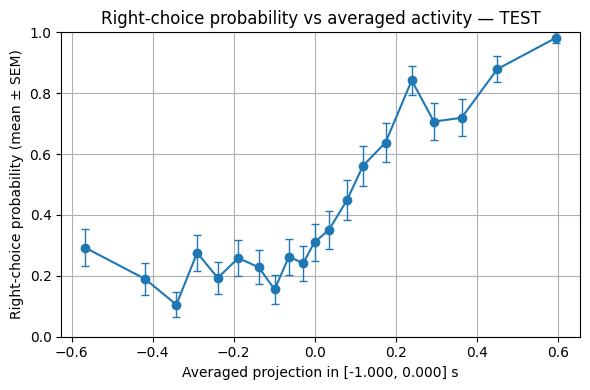

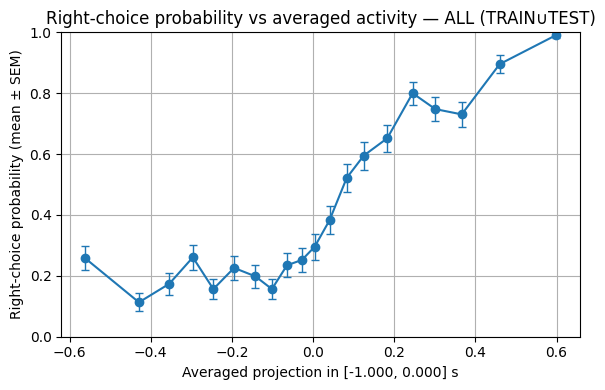

In [27]:
import os
import re
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from general_utils import smart_read_csv

# =========================
# Config
# =========================
base_dir = "/root/capsule/scratch/"

# Choose which files to use by suffix in the filename
# Examples:
# target_suffix = "_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0"
# target_suffix = "_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2"
target_suffix = "_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_-1_0"
#target_suffix = "_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0"

# Match only CD_* files containing the desired suffix
zarr_glob = os.path.join(base_dir, f"CD_results/CD_*{target_suffix}.zarr")

# Window over which to average activity for the choice-probability analysis
activity_avg_window = (-1, 0)

# Binning config
binning_method = "quantile"  # "quantile" or "uniform"
n_bins = 20
error_mode = "SEM"            # "SD" or "SEM"

# Extract session name between "CD_" and "_RG_"
session_re = re.compile(r"^CD_(?P<session>.+?)_RG_")

# =========================
# Helpers
# =========================
def build_choice_vector(trial_ids, df_behavior):
    """
    Map per-trial choices aligned to trial_ids.
    Returns float array with 1.0 for right, 0.0 for left, np.nan if neither
    (e.g., no-response / unknown).
    """
    try:
        left_trials = np.asarray(df_behavior["left_choice_trials"][0], dtype=int)
    except KeyError:
        left_trials = np.asarray([], dtype=int)
    try:
        right_trials = np.asarray(df_behavior["right_choice_trials"][0], dtype=int)
    except KeyError:
        right_trials = np.asarray([], dtype=int)

    left_set = set(left_trials.tolist())
    right_set = set(right_trials.tolist())

    choice = np.full(trial_ids.shape[0], np.nan, dtype=float)
    for i, tid in enumerate(trial_ids):
        if tid in right_set:
            choice[i] = 1.0
        elif tid in left_set:
            choice[i] = 0.0
    return choice


def time_window_mask(t, window):
    t0, t1 = window
    if t0 > t1:
        raise ValueError("activity_avg_window must satisfy t0 <= t1")
    return (t >= t0) & (t <= t1)


def bin_activity_and_compute_stats(x, y_right01, n_bins=10, method="quantile", error_mode="SD"):
    """
    x: activity (N,)
    y_right01: 0/1 choices (N,)
    Returns:
        bin_centers, right_prob_mean, right_prob_err, counts, method_used, edges
    """
    x = np.asarray(x)
    y = np.asarray(y_right01)

    if method == "quantile":
        qs = np.linspace(0, 1, n_bins + 1)
        edges = np.unique(np.quantile(x, qs))
        if edges.size < 3:  # pathological (e.g., constant x)
            xmin, xmax = float(np.min(x)), float(np.max(x))
            edges = np.linspace(xmin, xmax, n_bins + 1)
            method_used = "uniform (fallback)"
        else:
            method_used = "quantile"
    else:
        xmin, xmax = float(np.min(x)), float(np.max(x))
        edges = np.linspace(xmin, xmax, n_bins + 1)
        method_used = "uniform"

    inds = np.digitize(x, edges, right=False) - 1
    inds = np.clip(inds, 0, len(edges) - 2)

    means, errs, centers, counts = [], [], [], []
    for b in range(len(edges) - 1):
        mask = inds == b
        cnt = int(np.sum(mask))
        counts.append(cnt)

        if cnt > 0:
            p = float(np.mean(y[mask]))
            if cnt > 1:
                sd = float(np.std(y[mask], ddof=1))
            else:
                sd = 0.0
            err = sd if error_mode == "SD" else (sd / np.sqrt(cnt) if cnt > 0 else np.nan)
            c = float(np.mean(x[mask]))
        else:
            p = np.nan
            err = np.nan
            c = float(0.5 * (edges[b] + edges[b + 1]))

        means.append(p)
        errs.append(err)
        centers.append(c)

    return (
        np.asarray(centers),
        np.asarray(means),
        np.asarray(errs),
        np.asarray(counts),
        method_used,
        np.asarray(edges),
    )

# =========================
# Accumulators for (Y_avg, choice) per split
# =========================
choice_prob_data = {
    "train": {"Yavg": [], "choice": []},
    "test":  {"Yavg": [], "choice": []},
}

global_time = None
global_dt = np.nan

# =========================
# Main loop over sessions
# =========================
for zpath in sorted(glob.glob(zarr_glob)):
    zname = os.path.basename(zpath)

    m = session_re.match(zname)
    if not m:
        print(f"[skip] cannot extract session from: {zname}")
        continue

    session_name = m.group("session")
    beh_csv = os.path.join(base_dir, f"behavior_summary/behavior_summary-{session_name}.csv")
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {zname} -> {beh_csv}")
        continue

    print(f"\n=== Session: {session_name} ===")
    print(f"Zarr: {zpath}")
    print(f"CSV : {beh_csv}")

    # --- Load behavior + CD dataset ---
    df = smart_read_csv(beh_csv)
    ds = xr.open_zarr(zarr_path := zpath, consolidated=False)

    # --- Pull time + projections + IDs ---
    time = ds["time"].values
    dt = float(np.mean(np.diff(time))) if len(time) > 1 else np.nan
    if global_time is None:
        global_time = time
        global_dt = dt
    else:
        if len(time) == len(global_time) and np.allclose(time, global_time):
            pass
        else:
            print("[warn] time axis differs from previous sessions; averaging uses per-file mask.")

    tmask_avg = time_window_mask(time, activity_avg_window)

    # trial IDs
    trial_id_test_A  = np.asarray(ds["trial_id_test_A"].values, dtype=int)
    trial_id_test_B  = np.asarray(ds["trial_id_test_B"].values, dtype=int)
    trial_id_train_A = np.asarray(ds["trial_id_train_A"].values, dtype=int)
    trial_id_train_B = np.asarray(ds["trial_id_train_B"].values, dtype=int)

    # projection traces
    proj_train_A = ds["projection_trace_train_A"].values  # (n_trials, n_time)
    proj_train_B = ds["projection_trace_train_B"].values
    proj_test_A  = ds["projection_trace_test_A"].values
    proj_test_B  = ds["projection_trace_test_B"].values

    # Choices aligned to each block
    choice_train_A = build_choice_vector(trial_id_train_A, df)
    choice_train_B = build_choice_vector(trial_id_train_B, df)
    choice_test_A  = build_choice_vector(trial_id_test_A, df)
    choice_test_B  = build_choice_vector(trial_id_test_B, df)

    # Average activity in the window
    def avg_in_window(X):
        if isinstance(X, np.ndarray) and X.ndim == 2 and X.size > 0:
            if not np.any(tmask_avg):
                raise ValueError(f"No time samples in window {activity_avg_window}.")
            return np.nanmean(X[:, tmask_avg], axis=1)
        return np.asarray([], dtype=float)

    Yavg_train_A = avg_in_window(proj_train_A)
    Yavg_train_B = avg_in_window(proj_train_B)
    Yavg_test_A  = avg_in_window(proj_test_A)
    Yavg_test_B  = avg_in_window(proj_test_B)

    # Accumulate TRAIN
    if Yavg_train_A.size:
        valid = ~np.isnan(choice_train_A)
        choice_prob_data["train"]["Yavg"].append(Yavg_train_A[valid])
        choice_prob_data["train"]["choice"].append(choice_train_A[valid])
    if Yavg_train_B.size:
        valid = ~np.isnan(choice_train_B)
        choice_prob_data["train"]["Yavg"].append(Yavg_train_B[valid])
        choice_prob_data["train"]["choice"].append(choice_train_B[valid])

    # Accumulate TEST
    if Yavg_test_A.size:
        valid = ~np.isnan(choice_test_A)
        choice_prob_data["test"]["Yavg"].append(Yavg_test_A[valid])
        choice_prob_data["test"]["choice"].append(choice_test_A[valid])
    if Yavg_test_B.size:
        valid = ~np.isnan(choice_test_B)
        choice_prob_data["test"]["Yavg"].append(Yavg_test_B[valid])
        choice_prob_data["test"]["choice"].append(choice_test_B[valid])

# =========================
# Choice-probability plots only
# =========================
def concat_choice_prob_data(split_key):
    if not choice_prob_data[split_key]["Yavg"]:
        return np.asarray([], dtype=float), np.asarray([], dtype=float)
    X = np.concatenate(choice_prob_data[split_key]["Yavg"], axis=0)
    Y = np.concatenate(choice_prob_data[split_key]["choice"], axis=0).astype(float)
    return X, Y


X_train, Y_train = concat_choice_prob_data("train")
X_test,  Y_test  = concat_choice_prob_data("test")
X_all = np.concatenate([X_train, X_test], axis=0) if X_train.size or X_test.size else np.asarray([], dtype=float)
Y_all = np.concatenate([Y_train, Y_test], axis=0) if Y_train.size or Y_test.size else np.asarray([], dtype=float)


def plot_choice_prob_vs_activity(X, Y, title_suffix):
    if X.size == 0:
        print(f"[choice-prob] No data for {title_suffix}; skip.")
        return
    centers, means, errs, counts, method_used, edges = bin_activity_and_compute_stats(
        X, Y, n_bins=n_bins, method=binning_method, error_mode=error_mode
    )
    print(f"[choice-prob] {title_suffix}: {method_used} binning, counts={counts.tolist()}")
    fig = plt.figure(figsize=(6, 4))
    plt.errorbar(
        centers, means, yerr=errs,
        fmt="-o", elinewidth=1, capsize=3,
    )
    plt.xlabel(f"Averaged projection in [{activity_avg_window[0]:.3f}, {activity_avg_window[1]:.3f}] s")
    ylabel = "Right-choice probability (mean ± SD)" if error_mode == "SD" else "Right-choice probability (mean ± SEM)"
    plt.ylabel(ylabel)
    plt.title(f"Right-choice probability vs averaged activity — {title_suffix}")
    plt.grid(True, which="both", axis="both")
    plt.ylim(0, 1)
    plt.tight_layout()


plot_choice_prob_vs_activity(X_train, Y_train, "TRAIN")
plot_choice_prob_vs_activity(X_test,  Y_test,  "TEST")
plot_choice_prob_vs_activity(X_all,   Y_all,   "ALL (TRAIN∪TEST)")

plt.show()
